In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')   

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
matplotlib.rcParams['font.family'] ='AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] =False

In [ ]:
jinju = pd.read_csv('./data/final.csv', index_col=0)
print(jinju.shape)
jinju.head(2)

(13207, 10)


,도로조건,계약면적(㎡),건축년도,year,month,전세전환가격,coivd,price_per_m2,전월세구분_월세,전월세구분_전세
0,25,12.0,2016,2019,2,8435,0,702.916667,True,False
1,8,12.0,2016,2019,1,4500,0,375.000000,False,True


In [4]:
X = jinju.drop(["price_per_m2"], axis=1)
y = jinju['price_per_m2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1645)

X_train.head(2)

,도로조건,계약면적(㎡),건축년도,year,month,전세전환가격,coivd,전월세구분_월세,전월세구분_전세
4766,25,65.0,2012,2018,6,10000,0,False,True
121,8,26.0,1989,2019,2,7024,0,True,False


## ML

### Ridge

In [5]:
R_model = Ridge()
R_model.fit(X_train, y_train)
y_pred = R_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.7425995563361123

### Lasso

In [6]:
L_model = Lasso(alpha=0.5)
L_model.fit(X_train, y_train)
y_pred = L_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.7426242683106125

### ElasticNet

In [7]:
ela = ElasticNet(alpha=0.5)
ela.fit(X_train, y_train)
y_pred = ela.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.7393525060006458

### RandomForest

In [8]:
randomforest = RandomForestRegressor(random_state=0, n_jobs=-1)
randomforest.fit(X_train, y_train)
y_pred = randomforest.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9962471235635592

### GBM

In [9]:
gbm = GradientBoostingRegressor()
gbm.fit(X_train, y_train)
y_pred = gbm.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2


0.9950727547405726

### LightGBM

In [10]:
lightgbm = lgb.LGBMRegressor()
lightgbm.fit(X_train, y_train)
y_pred = lightgbm.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 10565, number of used features: 9
[LightGBM] [Info] Start training from score 208.131394


0.9963438306312647

### XGBoost

In [11]:
xgboost = XGBRegressor()
xgboost.fit(X_train, y_train)
y_pred = xgboost.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9926987627326582

## Hyperparameter tuning

In [12]:
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import mean_squared_error

# 랜덤 시드 고정
sampler = TPESampler(seed=10)

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbose': -1,
        'num_leaves': trial.suggest_int('num_leaves', 2, 1024, log=True),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_uniform('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_uniform('reg_lambda', 0.0, 10.0),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-8, 1e-2),
        'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_loguniform('subsample', 0.4, 1),
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=25),
            lgb.log_evaluation(period=0)  # 로그 출력 억제
        ]
    )
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds, squared=False)

study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100)


[I 2025-05-02 22:58:16,308] A new study created in memory with name: no-name-2d49c979-1374-46ab-8e63-0932ca6a60e3


Training until validation scores don't improve for 25 rounds


[I 2025-05-02 22:58:19,769] Trial 0 finished with value: 101.21372642928606 and parameters: {'num_leaves': 230, 'colsample_bytree': 0.7062255848078204, 'reg_alpha': 0.6336482349262754, 'reg_lambda': 7.488038825386118, 'max_depth': 9, 'learning_rate': 2.2324403996622945e-07, 'n_estimators': 674, 'min_child_samples': 78, 'subsample': 0.46704202331689854}. Best is trial 0 with value: 101.21372642928606.


Did not meet early stopping. Best iteration is:
[674]	valid_0's rmse: 101.214
Training until validation scores don't improve for 25 rounds


[I 2025-05-02 22:58:20,617] Trial 1 finished with value: 61.67287678174077 and parameters: {'num_leaves': 3, 'colsample_bytree': 0.9056079455103392, 'reg_alpha': 0.9533933461949365, 'reg_lambda': 0.039482663279144514, 'max_depth': 9, 'learning_rate': 0.0007511484404875245, 'n_estimators': 1876, 'min_child_samples': 74, 'subsample': 0.5226478358414336}. Best is trial 1 with value: 61.67287678174077.


...

Did not meet early stopping. Best iteration is:
[2302]	valid_0's rmse: 20.9941
Training until validation scores don't improve for 25 rounds


[I 2025-05-02 23:12:32,405] Trial 98 finished with value: 10.110872620654352 and parameters: {'num_leaves': 4, 'colsample_bytree': 0.7340494194999005, 'reg_alpha': 0.2920259109650669, 'reg_lambda': 2.6305259980024562, 'max_depth': 9, 'learning_rate': 0.007115477592669218, 'n_estimators': 2365, 'min_child_samples': 21, 'subsample': 0.616283639260797}. Best is trial 82 with value: 6.097380672027369.


Did not meet early stopping. Best iteration is:
[2365]	valid_0's rmse: 10.1109
Training until validation scores don't improve for 25 rounds


[I 2025-05-02 23:12:36,411] Trial 99 finished with value: 101.18108374696905 and parameters: {'num_leaves': 15, 'colsample_bytree': 0.7218059039197304, 'reg_alpha': 0.19357374795466709, 'reg_lambda': 3.3972606542979693, 'max_depth': 10, 'learning_rate': 2.640794854928758e-07, 'n_estimators': 2489, 'min_child_samples': 7, 'subsample': 0.6475637219981035}. Best is trial 82 with value: 6.097380672027369.


Did not meet early stopping. Best iteration is:
[2489]	valid_0's rmse: 101.181


In [13]:
optuna.visualization.plot_param_importances(study)

In [14]:
trial = study.best_trial
trial_params = trial.params
print('Best Trial: score {},\nparams {}'.format(trial.value, trial_params))

Best Trial: score 6.097380672027369,
params {'num_leaves': 24, 'colsample_bytree': 0.7483160721966106, 'reg_alpha': 0.3020217944143935, 'reg_lambda': 8.197538290345536, 'max_depth': 9, 'learning_rate': 0.0068111160047494325, 'n_estimators': 2529, 'min_child_samples': 7, 'subsample': 0.6884669269010173}


In [15]:
final_model = lgb.LGBMRegressor(**trial_params)
# final_model = XGBRegressor(**trial_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9963650478732151

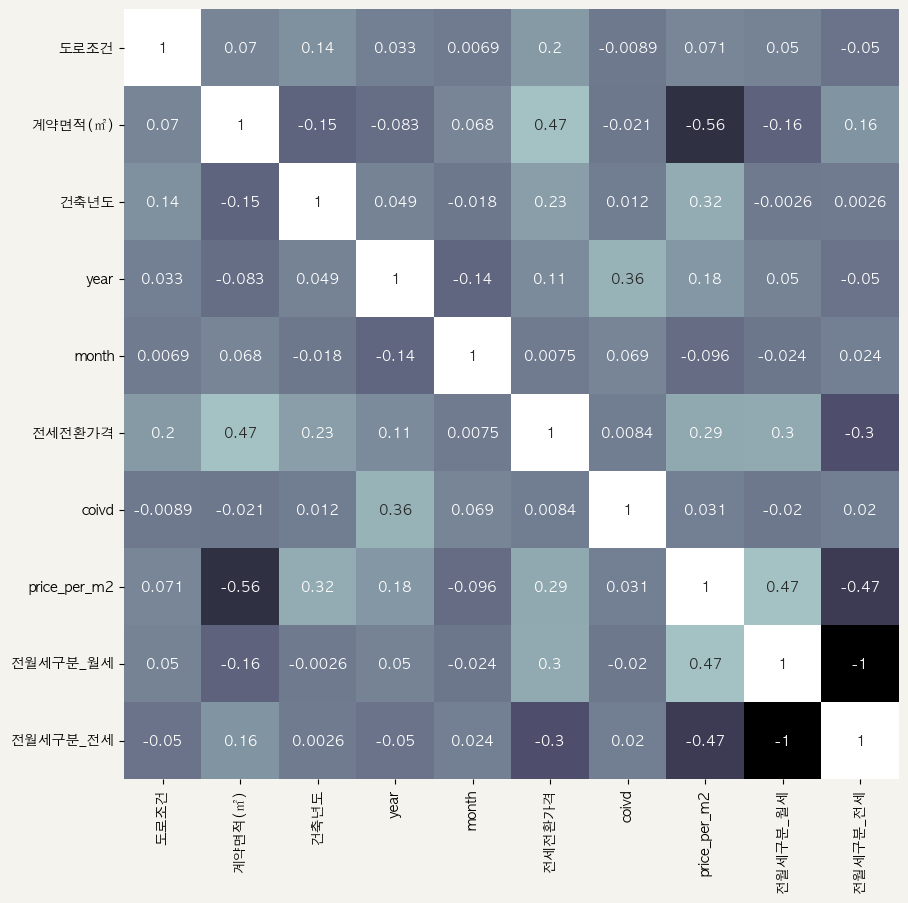

In [16]:
corr = jinju.corr()
plt.figure(figsize = (10, 10), facecolor = "#F5F3ED")
sns.heatmap(corr, annot = True, cbar = False,cmap = "bone")
plt.show()

In [17]:
final_model

LGBMRegressor(colsample_bytree=0.7483160721966106,
              learning_rate=0.0068111160047494325, max_depth=9,
              min_child_samples=7, n_estimators=2529, num_leaves=24,
              reg_alpha=0.3020217944143935, reg_lambda=8.197538290345536,
              subsample=0.6884669269010173)

In [18]:
final_model.booster_.save_model('./model/lh_home.txt')

In [19]:
import pandas as pd

def predict():
    load_model = lgb.Booster(model_file='./model/lh_home.txt')

    road = int(input("도로조건을 입력하세요 : "))
    m2 = int(input("거주면적을 입력하세요 : "))
    built = int(input("건축년도를 입력하세요 : "))
    year = int(input("계약년도를 입력하세요 : "))
    month = int(input("계약월을 입력하세요 : "))
    deposit = int(input("보증금을 입력하세요 : (만원)"))
    rate = 6
    
    x = [road, m2, built, year, month, 1, 0]

    y = [['도로조건', '계약면적(㎡)', '건축년도', 'year', 'month', '전월세구분_월세', '전월세구분_전세']]
    data = pd.DataFrame(x, y)
    data = data.T

    load_model = lgb.Booster(model_file='./model/lh_home.txt')
    price = load_model.predict(data) * m2
    pred = (price - deposit) * rate / 1200
    return pred

In [ ]:
print(predict())